# 05 Classification Models

In this notebook, we train and evaluate multiple machine learning models for the authorship classification task.

The goal is to compare the performance of different classification algorithms on the Reuter_50_50 dataset.

The following models will be evaluated:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine
- K-Nearest Neighbors
- Random Forest

Model performance will be evaluated using several standard classification metrics:

- accuracy
- macro-averaged precision
- macro-averaged recall
- macro-averaged F1-score

These metrics are especially important because the task involves **50 classes**, and macro-averaging gives equal importance to each author.

In [1]:
import pickle
import pandas as pd
import numpy as np
import time

from pathlib import Path

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
FEATURE_PATH = Path("../processed/features/features.pkl")

with open(FEATURE_PATH, "rb") as f:
    data = pickle.load(f)

X_train_full = data["X_train_full"]
X_test_full = data["X_test_full"]
X_train_3000 = data["X_train_3000"]
X_test_3000 = data["X_test_3000"]
X_train_1000 = data["X_train_1000"]
X_test_1000 = data["X_test_1000"]
y_train = data["y_train"]
y_test = data["y_test"]

print("X_train_full:", X_train_full.shape)
print("X_test_full:", X_test_full.shape)
print("Classes:", y_train.nunique())

X_train_full: (2500, 5000)
X_test_full: (2500, 5000)
Classes: 50


In [3]:
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVM": LinearSVC(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

In [4]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    start_time = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    elapsed_time = time.time() - start_time

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "time_seconds": elapsed_time
    }

In [5]:
results_full = []

for name, model in models.items():
    print(f"Training {name}...")
    metrics = evaluate_model(model, X_train_full, X_test_full, y_train, y_test)
    metrics["model"] = name
    metrics["feature_set"] = "full_5000"
    results_full.append(metrics)

results_full_df = pd.DataFrame(results_full)
results_full_df = results_full_df[
    ["model", "feature_set", "accuracy", "precision_macro", "recall_macro", "f1_macro", "time_seconds"]
].sort_values(by="f1_macro", ascending=False)

results_full_df

Training MultinomialNB...
Training LogisticRegression...
Training LinearSVM...
Training KNN...
Training RandomForest...


,model,feature_set,accuracy,precision_macro,recall_macro,f1_macro,time_seconds
2,LinearSVM,full_5000,0.6712,0.675921,0.6712,0.666774,0.496025
4,RandomForest,full_5000,0.6472,0.656235,0.6472,0.637960,2.917085
1,LogisticRegression,full_5000,0.6364,0.652470,0.6364,0.632667,1.047016
0,MultinomialNB,full_5000,0.6272,0.647337,0.6272,0.616248,0.034202
3,KNN,full_5000,0.5512,0.564988,0.5512,0.550054,0.404205


## Classification results on the full TF-IDF feature set

In this experiment, five classification algorithms were trained and evaluated using the full TF-IDF representation with **5000 features**.

The models were compared using accuracy, macro-averaged precision, macro-averaged recall, and macro-averaged F1-score.

Because the dataset contains **50 balanced classes**, macro-averaged metrics are particularly important. Unlike weighted metrics, macro-averaging treats all classes equally and therefore provides a fairer view of model performance across all authors.

In addition to predictive performance, training and prediction time was also recorded in order to compare the computational efficiency of the algorithms.

## Model performance comparison (5000 features)

The results show clear differences in performance between the evaluated classification algorithms.

Among the tested models, **Linear Support Vector Machines (Linear SVM)** achieved the best overall performance with an accuracy of approximately **67%** and the highest macro-averaged F1-score.

This result is consistent with expectations for text classification tasks. SVM models are particularly well suited for **high-dimensional sparse data**, such as TF-IDF document representations.

The **Random Forest** model achieved the second-best performance, suggesting that some nonlinear patterns exist in the dataset.

**Logistic Regression** and **Multinomial Naive Bayes** produced similar results, which is also common in text classification tasks where both models can perform well on bag-of-words representations.

The **K-Nearest Neighbors (KNN)** model performed noticeably worse than the other algorithms. This behavior can be explained by the **curse of dimensionality**, which negatively affects distance-based algorithms in high-dimensional feature spaces.

Overall, the results indicate that **Linear SVM is the most suitable model for this authorship classification task when using the full TF-IDF feature set**.

In [6]:
results_3000 = []

for name, model in models.items():
    print(f"Training {name} (3000 features)...")
    metrics = evaluate_model(model, X_train_3000, X_test_3000, y_train, y_test)
    metrics["model"] = name
    metrics["feature_set"] = "reduced_3000"
    results_3000.append(metrics)

results_3000_df = pd.DataFrame(results_3000)
results_3000_df = results_3000_df[
    ["model", "feature_set", "accuracy", "precision_macro", "recall_macro", "f1_macro", "time_seconds"]
].sort_values(by="f1_macro", ascending=False)

results_3000_df

Training MultinomialNB (3000 features)...
Training LogisticRegression (3000 features)...
Training LinearSVM (3000 features)...
Training KNN (3000 features)...
Training RandomForest (3000 features)...


,model,feature_set,accuracy,precision_macro,recall_macro,f1_macro,time_seconds
4,RandomForest,reduced_3000,0.6636,0.673217,0.6636,0.656236,2.225059
2,LinearSVM,reduced_3000,0.6576,0.662946,0.6576,0.653732,0.284191
1,LogisticRegression,reduced_3000,0.6292,0.645821,0.6292,0.625568,0.647614
0,MultinomialNB,reduced_3000,0.6124,0.634400,0.6124,0.600927,0.021414
3,KNN,reduced_3000,0.5424,0.568400,0.5424,0.545169,0.314589


In [7]:
results_1000 = []

for name, model in models.items():
    print(f"Training {name} (1000 features)...")
    metrics = evaluate_model(model, X_train_1000, X_test_1000, y_train, y_test)
    metrics["model"] = name
    metrics["feature_set"] = "reduced_1000"
    results_1000.append(metrics)

results_1000_df = pd.DataFrame(results_1000)
results_1000_df = results_1000_df[
    ["model", "feature_set", "accuracy", "precision_macro", "recall_macro", "f1_macro", "time_seconds"]
].sort_values(by="f1_macro", ascending=False)

results_1000_df

Training MultinomialNB (1000 features)...
Training LogisticRegression (1000 features)...
Training LinearSVM (1000 features)...
Training KNN (1000 features)...
Training RandomForest (1000 features)...


,model,feature_set,accuracy,precision_macro,recall_macro,f1_macro,time_seconds
4,RandomForest,reduced_1000,0.6280,0.635275,0.6280,0.622613,1.086981
2,LinearSVM,reduced_1000,0.6120,0.611499,0.6120,0.604895,0.123981
1,LogisticRegression,reduced_1000,0.5880,0.604627,0.5880,0.583655,0.291165
0,MultinomialNB,reduced_1000,0.5876,0.599961,0.5876,0.573352,0.009443
3,KNN,reduced_1000,0.4644,0.555423,0.4644,0.486006,0.168766


## Comparison of different feature set sizes

To analyze the impact of dimensionality reduction, classification models were trained using three different feature sets:

- **Full TF-IDF representation (5000 features)**
- **Reduced feature set (3000 features)**
- **Reduced feature set (1000 features)**

The results show that reducing the number of features from **5000 to 3000** has only a small impact on performance. In fact, some models such as Random Forest achieve nearly identical accuracy with fewer features.

However, when the feature space is reduced further to **1000 features**, model performance decreases more noticeably. This suggests that some important information is lost when too many features are removed.

These results indicate that a feature space of around **3000 features provides a good balance between model performance and computational efficiency**.

Additionally, different algorithms respond differently to feature reduction. Linear SVM performs best with the full high-dimensional TF-IDF representation, while Random Forest benefits from smaller feature spaces.

Overall, the experiments demonstrate the importance of carefully selecting the dimensionality of the feature space when building text classification models.

In [8]:
all_results = pd.concat([
    results_full_df,
    results_3000_df,
    results_1000_df
])

all_results = all_results.sort_values(by="f1_macro", ascending=False)

all_results

,model,feature_set,accuracy,precision_macro,recall_macro,f1_macro,time_seconds
2,LinearSVM,full_5000,0.6712,0.675921,0.6712,0.666774,0.496025
4,RandomForest,reduced_3000,0.6636,0.673217,0.6636,0.656236,2.225059
2,LinearSVM,reduced_3000,0.6576,0.662946,0.6576,0.653732,0.284191
4,RandomForest,full_5000,0.6472,0.656235,0.6472,0.637960,2.917085
1,LogisticRegression,full_5000,0.6364,0.652470,0.6364,0.632667,1.047016
1,LogisticRegression,reduced_3000,0.6292,0.645821,0.6292,0.625568,0.647614
4,RandomForest,reduced_1000,0.6280,0.635275,0.6280,0.622613,1.086981
0,MultinomialNB,full_5000,0.6272,0.647337,0.6272,0.616248,0.034202
2,LinearSVM,reduced_1000,0.6120,0.611499,0.6120,0.604895,0.123981
0,MultinomialNB,reduced_3000,0.6124,0.634400,0.6124,0.600927,0.021414


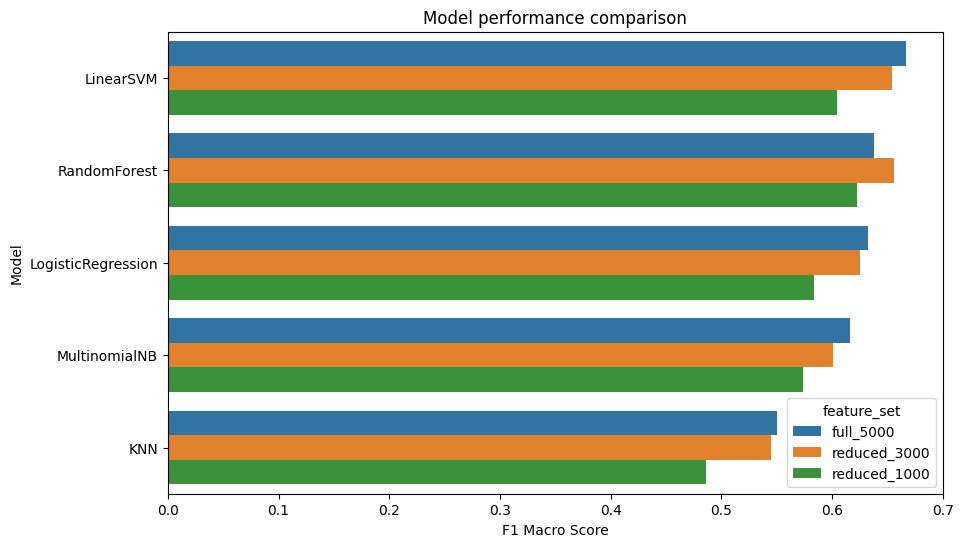

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=all_results,
    x="f1_macro",
    y="model",
    hue="feature_set"
)

plt.title("Model performance comparison")
plt.xlabel("F1 Macro Score")
plt.ylabel("Model")

plt.show()

## Final conclusions

In this notebook, five machine learning algorithms were evaluated for the task of authorship classification on the Reuter_50_50 dataset.

The experiments compared model performance across different feature set sizes, including the full TF-IDF representation and two reduced feature spaces.

The results show that **Linear SVM achieves the best performance when using the full TF-IDF feature set**, while **Random Forest performs competitively when the feature space is reduced**.

Reducing the feature space to **3000 features maintains similar performance while improving computational efficiency**, whereas reducing the feature set to **1000 features leads to a noticeable decrease in accuracy.

These findings demonstrate that careful feature selection can significantly reduce dimensionality without substantially affecting model performance.

Overall, the experiments confirm that **Linear SVM and Random Forest are strong candidates for authorship classification tasks using TF-IDF representations**.